In [32]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from mpl_toolkits.mplot3d import Axes3D
import math

In [33]:
E_sigma=3
data = np.load(f"D:\PENTING KUYLAH\code\Bajr\data_A_{E_sigma}.npy")
earth_pos=np.load(f"D:\PENTING KUYLAH\code\Bajr\earth_pos_A_{E_sigma}.npy")
moon_pos=np.load(f"D:\PENTING KUYLAH\code\Bajr\moon_pos_A_{E_sigma}.npy")




<>:2: SyntaxWarning: invalid escape sequence '\P'
<>:3: SyntaxWarning: invalid escape sequence '\P'
<>:4: SyntaxWarning: invalid escape sequence '\P'
<>:2: SyntaxWarning: invalid escape sequence '\P'
<>:3: SyntaxWarning: invalid escape sequence '\P'
<>:4: SyntaxWarning: invalid escape sequence '\P'
C:\Users\wilda\AppData\Local\Temp\ipykernel_20696\3867207137.py:2: SyntaxWarning: invalid escape sequence '\P'
  data = np.load(f"D:\PENTING KUYLAH\code\Bajr\data_A_{E_sigma}.npy")
C:\Users\wilda\AppData\Local\Temp\ipykernel_20696\3867207137.py:3: SyntaxWarning: invalid escape sequence '\P'
  earth_pos=np.load(f"D:\PENTING KUYLAH\code\Bajr\earth_pos_A_{E_sigma}.npy")
C:\Users\wilda\AppData\Local\Temp\ipykernel_20696\3867207137.py:4: SyntaxWarning: invalid escape sequence '\P'
  moon_pos=np.load(f"D:\PENTING KUYLAH\code\Bajr\moon_pos_A_{E_sigma}.npy")


In [34]:
print(data.shape)
print(earth_pos.shape)
print(moon_pos.shape)


(1441, 10000, 3)
(1441, 3)
(1441, 3)


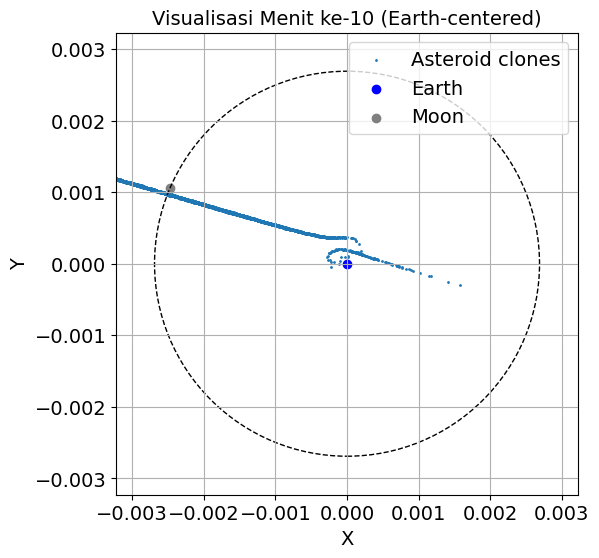

In [35]:
import numpy as np
import matplotlib.pyplot as plt


t = 900

asteroid = data[t]          # (2000, 3)
earth = earth_pos[t]        # (3,)
moon = moon_pos[t]          # (3,)

# Geser koordinat -> bumi jadi (0,0,0)
asteroid_rel = asteroid - earth
moon_rel = moon - earth

# Ambil hanya x dan y
asteroid_xy = asteroid_rel[:, :2]
moon_xy = moon_rel[:2]

# Hitung radius orbit bulan
moon_radius = np.linalg.norm(moon_xy)

# Plot
plt.figure(figsize=(6,6))

# Asteroid
plt.scatter(asteroid_xy[:,0], asteroid_xy[:,1], s=1, label='Asteroid clones')

# Bumi (0,0)
plt.scatter(0, 0, color='blue', label='Earth')

# Bulan
plt.scatter(moon_xy[0], moon_xy[1], color='gray', label='Moon')

# Lingkaran orbit bulan
circle = plt.Circle((0, 0), moon_radius, fill=False, linestyle='--')
plt.gca().add_patch(circle)

# Set limit sesuai orbit bulan
limit = moon_radius * 1.2
plt.xlim(-limit, limit)
plt.ylim(-limit, limit)

plt.gca().set_aspect('equal', adjustable='box')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Visualisasi Menit ke-10 (Earth-centered)')
plt.legend(loc='upper right')
plt.grid()

plt.show()

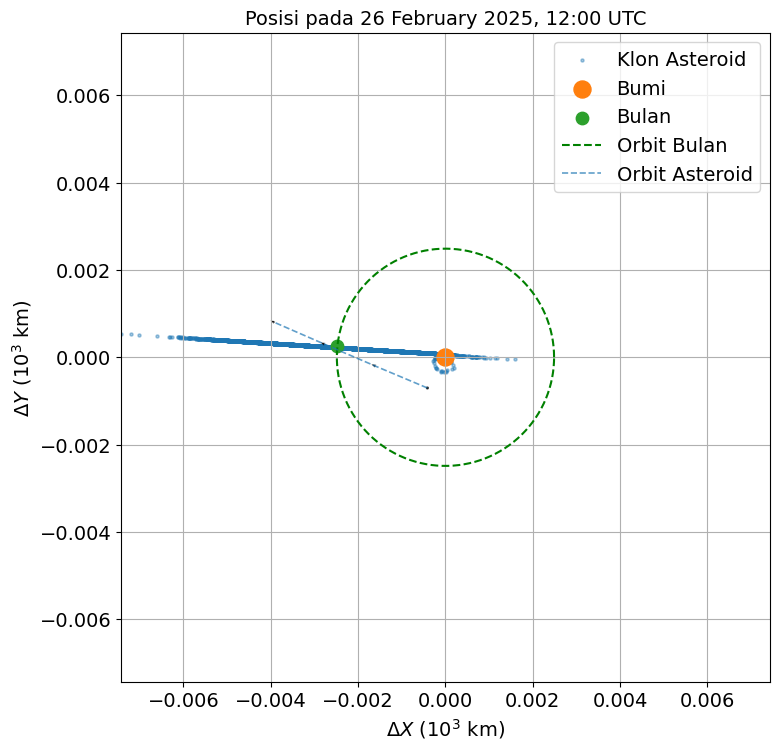

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta, timezone

f_size = 14

# Samakan ukuran font
plt.rcParams.update({
    "font.size": f_size,
    "axes.titlesize": f_size,
    "axes.labelsize": f_size,
    "xtick.labelsize": f_size,
    "ytick.labelsize": f_size,
    "legend.fontsize": f_size
})

# =========================
# WAKTU
# =========================
t0 = datetime(2025, 1, 20, 0, 0, tzinfo=timezone.utc)
t_idx = 900  # dalam menit

current_time = t0 + timedelta(hours=int(t_idx))
waktu_str = current_time.strftime("%d %B %Y, %H:%M UTC")

# =========================
# AMBIL DATA
# =========================
clone_pos = data[t_idx]
earth = earth_pos[t_idx]
moon = moon_pos[t_idx]

# Relatif terhadap Earth
rel_clone = clone_pos - earth
rel_moon = moon - earth

x = rel_clone[:, 0]
y = rel_clone[:, 2]

moon_x = rel_moon[0]
moon_y = rel_moon[2]

plt.figure(figsize=(8, 8))

# =========================
# KLON ASTEROID (snapshot)
# =========================
plt.scatter(x, y, s=5, alpha=0.4, label="Klon Asteroid")

# Earth di pusat
plt.scatter(0, 0, s=150, marker='o', label="Bumi")

# Moon (posisi saat t_idx)
plt.scatter(moon_x, moon_y, s=80, marker='o', label="Bulan")

# =========================
# ORBIT BULAN (LINGKARAN PENUH)
# =========================
r_moon = np.sqrt(moon_x**2 + moon_y**2)

theta = np.linspace(0, 2*np.pi, 500)
orbit_moon_x = r_moon * np.cos(theta)
orbit_moon_y = r_moon * np.sin(theta)

plt.plot(
    orbit_moon_x,
    orbit_moon_y,
    linestyle='--',
    linewidth=1.5,
    label="Orbit Bulan",
    color="green"
)

# =========================
# ORBIT 1 KLON (dengan arah)
# =========================
clone_index = 0

clone_orbit_rel = data[:, clone_index, :] - earth_pos

orbit_ast_x = clone_orbit_rel[:, 0]
orbit_ast_y = clone_orbit_rel[:, 2]

# Garis orbit (tipis)
# Garis orbit (putus-putus)
plt.plot(
    orbit_ast_x,
    orbit_ast_y,
    linewidth=1.2,
    linestyle='--',
    alpha=0.7,
    label="Orbit Asteroid"
)

# Panah arah
step = 50  # atur kepadatan panah

dx = np.diff(orbit_ast_x, prepend=orbit_ast_x[0])
dy = np.diff(orbit_ast_y, prepend=orbit_ast_y[0])
# Perbesar panjang vektor secara manual
scale_factor = 50  # coba 10, 20, 50 sesuai kebutuhan
# =========================
# PANAH ARAH (JUMLAH TERKONTROL)
# =========================
n_arrows = 4  # jumlah panah yang kamu mau

indices = np.linspace(0, len(orbit_ast_x) - 2, n_arrows).astype(int)

scale_factor = 40

plt.quiver(
    orbit_ast_x[indices],
    orbit_ast_y[indices],
    dx[indices] * scale_factor,
    dy[indices] * scale_factor,
    angles='xy',
    scale_units='xy',
    scale=1,
    width=0.005,
    headwidth=4,
    headlength=6,
    alpha=0.9,
    
)

# =========================
# PUSATKAN EARTH
# =========================
max_range = max(
    np.max(np.abs(x)),
    np.max(np.abs(y)),
    np.max(np.abs(orbit_moon_x)),
    np.max(np.abs(orbit_moon_y))
)

plt.xlim(-max_range, max_range)
plt.ylim(-max_range, max_range)

plt.xlabel(r"$\Delta X$ ($10^{3}$ km)")
plt.ylabel(r"$\Delta Y$ ($10^{3}$ km)")

plt.gca().set_aspect('equal', adjustable='box')
plt.grid(True)

plt.title(f"Posisi pada {waktu_str}")

plt.legend(loc="upper right")

plt.tight_layout()

plt.savefig("posisi_close_approach_3.png", dpi=600, bbox_inches="tight")

plt.show()

In [40]:
dist_earth=np.zeros((1441,data.shape[1]))
for i in range (data.shape[1]):
    for j in range (1441):
        dist_earth[j,i] = math.sqrt(
        (data[j,i,0] - earth_pos[j,0])**2 +
        (data[j,i,1] - earth_pos[j,1])**2 +
        (data[j,i,2] - earth_pos[j,2])**2
        )
dist_earth_min=np.zeros(data.shape[1])
for i in range (data.shape[1]):
    dist_earth_min[i]=np.min(dist_earth[:,i])

earth_radius_au = 4.26352e-5
count = np.sum(dist_earth_min < earth_radius_au)
print(count)

36


In [41]:
dist_moon=np.zeros((1441,data.shape[1]))
for i in range (data.shape[1]):
    for j in range (1441):
        dist_moon[j,i] = math.sqrt(
        (data[j,i,0] - moon_pos[j,0])**2 +
        (data[j,i,1] - moon_pos[j,1])**2 +
        (data[j,i,2] - moon_pos[j,2])**2
        )
dist_moon_min=np.zeros(data.shape[1])
for i in range (data.shape[1]):
    dist_moon_min[i]=np.min(dist_moon[:,i])

moon_radius_au = 1.16e-5
count = np.sum(dist_moon_min < moon_radius_au)
print(count)

69
